In [ ]:
import numpy as np
xarr= [0.95,
   0.9595,
   0.9666,
    ]

y =       [[
    0.5426840783578046,
    0.551543876837394,
    0.5604036753169834,
    0.5692634737965729,
    0.5781232722761623,
    0.5869830707557517,
    0.5958428692353411,
    0.6047026677149305,
    0.61356246619452,
    0.6224222646741094
   ],
   [
    0.5051602309448364,
    0.523781759965639,
    0.5424032889864415,
    0.5610248180072441,
    0.5796463470280467,
    0.5982678760488492,
    0.6168894050696518,
    0.6355109340904543,
    0.654132463111257,
    0.6727539921320596
   ]]

z = [[
    0.9299656994480711,
    0.948639391209657,
    0.9683949904034378,
    0.9892324970294134,
    1.0111519110875844,
    1.0341532325779492,
    1.0582364615005093,
    1.0834015978552647,
    1.1096486416422144,
    1.136977592861359
   ],
   [
    0.8562135389103421,
    0.8727773034652001,
    0.8922582419837185,
    0.9146563544658971,
    0.9399716409117361,
    0.9682041013212354,
    0.9993537356943948,
    1.0334205440312152,
    1.0704045263316955,
    1.1103056825958362
   ]]
y=np.array(y)
z=np.array(z)


xpos = 1
yfrac = (xarr[xpos] - xarr[xpos - 1]) / (xarr[xpos+1] - xarr[xpos - 1])

yarr = (y[xpos - 1] - yfrac * y[xpos])/(1-yfrac)
zarr = (z[xpos - 1] - yfrac * z[xpos])/(1-yfrac)
print(f'y = {yarr.tolist()}')
print(f'z = {zarr.tolist()}')


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(y,z)
ax.scatter(yarr,zarr)
ax.grid(True)
plt.show()



In [ ]:
yfrac

In [ ]:
import pandas as pd
import numpy as np


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\compressor_results_test.csv', sep=',')

failed_count = (df['status'] == 'failed').sum()
print(f'Failed count: {failed_count}')


In [ ]:
import os
print(os.getpid())

: 

In [ ]:
import numpy as np

yarr = [4,3,1,5]
y = 4.1
ypos = np.searchsorted(yarr, y)
print(ypos)


In [7]:
import pandas as pd
df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\charmap_simulation_results_0.864.csv',sep=',')

cop_mean = df['cop_given'].mean()

RMSE = 0.082
mean_RMSE = RMSE / cop_mean
print(f'mean RMSE  = {round(mean_RMSE * 100,2)} %')

mean RMSE  = 2.87 %


In [ ]:
import pandas as pd
df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\compressor_results1.csv',sep=',')

eff1 = df['Comp1 eff'].max().round(2)
eff2 = df['Comp2 eff'].max().round(2)
print(eff1,eff2)


  Method   RMSE  Relative RMSE (%)  MAPE (%)     R²  Sigma  NMBE (%)
0      1  0.132               4.62      2.97  0.633  0.113      1.03
1      2  0.137               4.79      3.99  0.644  0.101      0.61
2      3  0.082               2.87      2.31  0.872  0.050      0.92
3      4  0.111               3.88      3.11  0.766  0.070      1.53
4      5  0.080               2.80      1.73  0.864  0.064      0.04
5      6  0.082               2.87      1.89  0.871  0.064      0.03


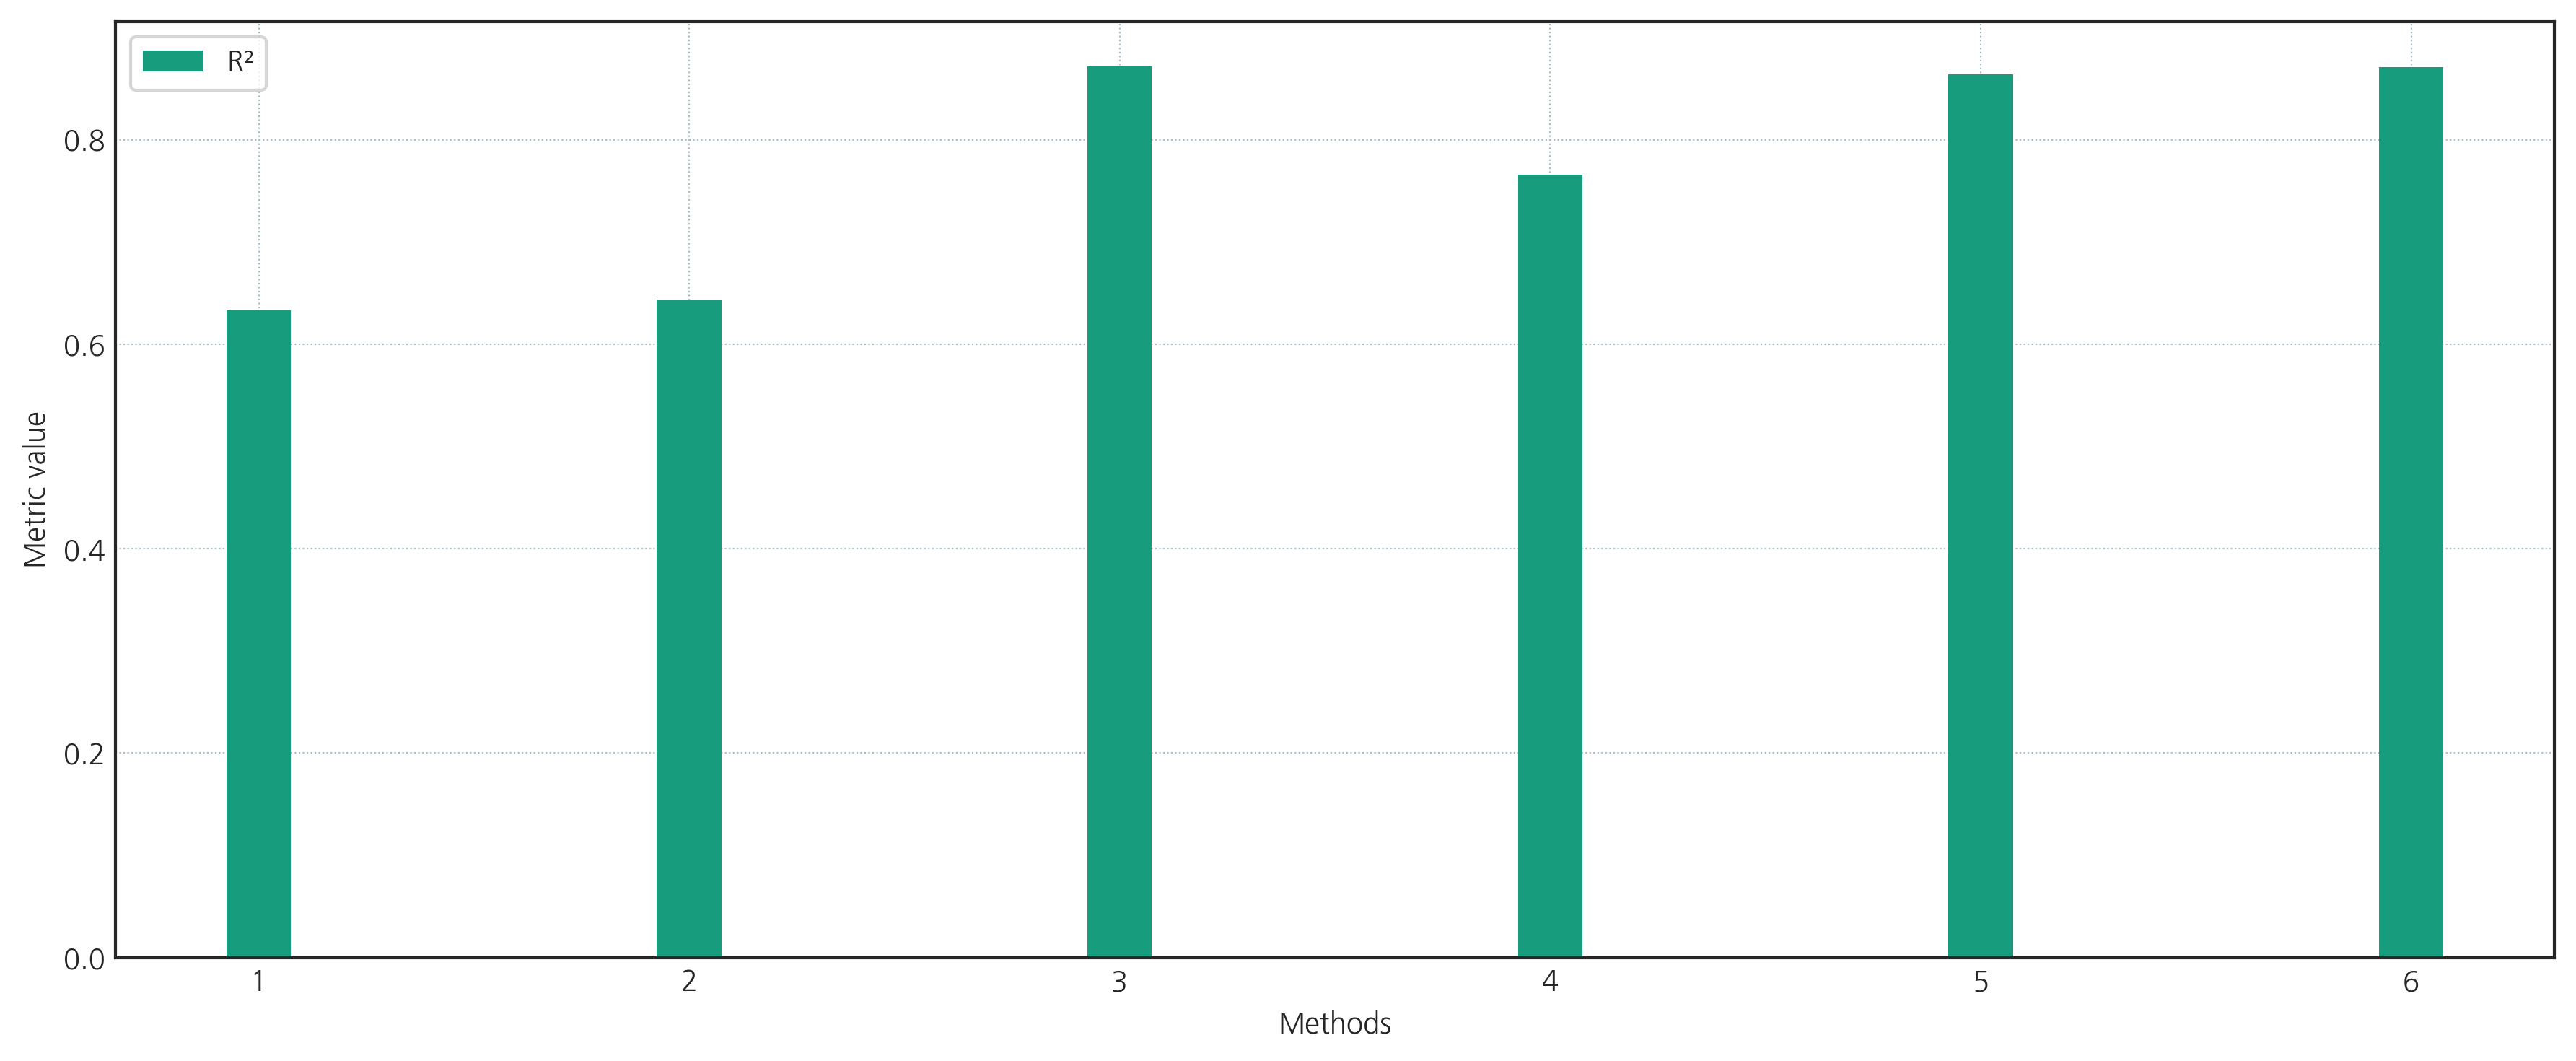

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import fhgcd_plots.main as fhgCD
import numpy as np

# Example values
df_metrics = pd.DataFrame({
    'Method': ['1', '2', '3','4','5','6'],
    'RMSE': [0.132, 0.137, 0.082,0.111,0.080,0.082],
    'Relative RMSE (%)': [4.62,4.79,2.87,3.88,2.8,2.87],
    'MAPE (%)': [2.97,3.99,2.31,3.11,1.73,1.89],
    'R²': [0.633,0.644,0.872,0.766,0.864,0.871],
    'Sigma': [0.113,0.101,0.050,0.070,0.064,0.064],
    'NMBE (%)': [1.03,0.61,0.92,1.53,0.04,0.03]
})

print(df_metrics)

#metrics_to_plot = ['Relative RMSE (%)', 'MAPE (%)',  'NMBE (%)']
#metrics_to_plot = ['RMSE',  'Sigma']
metrics_to_plot = ['R²']

x = np.arange(len(df_metrics['Method']))
width = 0.15

fhgCD.set_matplotlib_style("grid", "official")

fig, ax = plt.subplots(figsize=(12, 5))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, df_metrics[metric], width, label=metric)

ax.set_xticks(x + width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels(df_metrics['Method'])
ax.set_ylabel('Metric value')
ax.set_xlabel('Methods')
#ax.set_title('Comparison of error metrics for different methods')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\charmap_simulation_results_0.871.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
#df = df.sort_values('datetime').reset_index(drop=True)

# difference between consecutive timestamps
df['dt_diff'] = df['datetime'].diff()

expected = pd.Timedelta(minutes=15)

breaks = df[df['dt_diff'] > expected].copy()
breaks['previous_datetime'] = df['datetime'].shift(1)

breaks[['previous_datetime', 'datetime', 'dt_diff','cop','cop_given','Q']].to_csv('time_series_breaks.csv', index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\compressor_results1.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot: compressor efficiencies
ax1.scatter(df['datetime'], df['Comp1 eff'], label='Compressor 1')
ax1.scatter(df['datetime'], df['Comp2 eff'], label='Compressor 2')
ax1.set_ylabel('Isentropic efficiency')
ax1.set_xlabel('Date time')
ax1.set_title('Isentropic efficiency using real power as input')
ax1.legend()
ax1.grid(True, axis='y')

# Bottom plot: COP
ax2.plot(df['datetime'], df['cop_given'], label='COP given')
ax2.set_ylabel('COP')
ax2.set_xlabel('Date time')
ax2.set_title('COP over time')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\charmap_simulation_results_reverse.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot: compressor efficiencies
ax1.scatter(df['datetime'], df['eta1'], label='Compressor 1')
ax1.scatter(df['datetime'], df['eta2'], label='Compressor 2')
ax1.set_ylabel('Isentropic efficiency')
ax1.set_xlabel('Date time')
ax1.set_title('Isentropic efficiency using calibrated map as input')
ax1.legend()
ax1.grid(True, axis='y')

# Bottom plot: COP
ax2.plot(df['datetime'], df['cop'], label='COP simulated')
ax2.set_ylabel('COP')
ax2.set_xlabel('Date time')
ax2.set_title('COP over time')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_excel(r'h:\Master Thesis\gitlab\ma_ronit\data\process_data\Manheim_data_cleaned4.xlsx', sheet_name="Mannheim_rlgwp_2025-10-22", header=0,skiprows=range(1, 5)) #Load profile data

df['Column30'].describe()

In [1]:
2+2

4